In [37]:
#9-12-25
#clw prediction
#12 inputs and 1 output
#Mass-weighted random sampling
#data fraction from every height = 0.001 (0.1%) before mass-weighted random sampling #0.01% after mass-weighted rand sampling
#for ht in range(36, 91, 5) 
# start_time = 1979-01-12T00:00:00 
# end_time = 1979-01-12T00:00:00 


import time
overall_start_time = time.time()
import os
import sys

import numpy as np
import pandas as pd
#%matplotlib inline  #won't work for .py
import matplotlib.pyplot as plt
import xarray as xr

# import json_file_editer as JFE
from File_management import json_file_editer as JFE
from Calculation import job_manager 
from Tools import dataset_init
from Log_management import Log

import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

#random forest
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

#ISLP
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS

from sklearn.tree import (DecisionTreeClassifier as DTC,
 DecisionTreeRegressor as DTR,
 plot_tree,
 export_text)
from sklearn.metrics import (accuracy_score,
 log_loss)
from sklearn.ensemble import \
 (RandomForestRegressor as RF,
 GradientBoostingRegressor as GBR)
from ISLP.bart import BART

#################################################################
Log.init_log(os.path.join('./output'), filename=f"Log_ML.txt")
Log.add_to_log("Log nicely initialized ")

options_json=JFE.get_json_data("options.json")
options_json["Header"]["status"]
chunks = {}
myJob = job_manager.JobManager(options_json)
ds = dataset_init.ds_init_3d(myJob, chunks={}) 

The job folder path : ./output/Log_ML.txt
2025 Dec 10 19:48:49 > Log nicely initialized 
2025 Dec 10 19:48:49 > (DI0010) making data from P-O files requires small differences in the code, hardly automisable.
2025 Dec 10 19:48:49 > (DI0020) Starting PO dataset creation from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0001
2025 Dec 10 19:48:49 > (DI0021) Found 8 time-varying files in date range
2025 Dec 10 19:48:49 > (DI0022) Loading vertical grid data from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0001/pod0001_atm_vgrid_ml.nc
2025 Dec 10 19:48:49 > (DI0023) Grid variables available: ['clon_bnds', 'clat_bnds', 'height_bnds', 'height_2_bnds', 'zghalf', 'zg', 'dzghalf', 'clon', 'clat', 'height', 'height_2']
2025 Dec 10 19:48:49 > (DI0024) Dimensions in vgrid: FrozenMappingWarningOnValuesAccess({'ncells': 20971520, 'vertices': 3, 'height': 60, 'bnds': 2, 'height_2': 60})
2025 Dec 10 19:48:49 > (DI0037) Loading horizonta

In [38]:
seed = 1
sample_frac = 0.001

ht=31
data=ds.sel(height=ht, height_2=ht) 

total = data['clw'] + data['cli']
data['clw/(clw+cli)'] = data['clw'].where(total != 0, 0) / total.where(total != 0, 1)
data['cli/(clw+cli)'] = data['cli'].where(total != 0, 0) / total.where(total != 0, 1)

total_precipitates = data['qr'] + data['qs']+ data['qg']
data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)


In [39]:
df = data.to_dataframe() #.sample(frac=1, random_state=seed) #frac=sample_frac

In [40]:

# df = data.to_dataframe().sample(frac=sample_frac, random_state=seed)

dfs = [df]  
# for ht in range(32, 91, 5): #(32, 91, 5)
for ht in range(36, 91, 5): #(32, 91, 5)
    data = ds.sel(height=ht, height_2=ht)

    total = data['clw'] + data['cli']
    data['clw/(clw+cli)'] = data['clw'].where(total != 0, 0) / total.where(total != 0, 1)
    data['cli/(clw+cli)'] = data['cli'].where(total != 0, 0) / total.where(total != 0, 1)

    total_precipitates = data['qr'] + data['qs']+ data['qg']
    data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

    df_sampled=data.to_dataframe() #.sample(frac=1, random_state= seed+ht) #frac=sample_frac
    dfs.append(df_sampled) 
    print(f"Last value of clon in df with height {ht} is", df_sampled['clon'].iloc[-1])

df = pd.concat(dfs, ignore_index=True)

# print('length of dfs: ',len(dfs))
# print('len of dfs[0]: ', len(dfs[0]))
prod= len(dfs[0]) * len(dfs)
print("Expected length of df: ", prod)
print('Final length of df: ', len(df))

Last value of clon in df with height 36 is 1.3343108942333097
Last value of clon in df with height 41 is 1.3343108942333097
Last value of clon in df with height 46 is 1.3343108942333097
Last value of clon in df with height 51 is 1.3343108942333097
Last value of clon in df with height 56 is 1.3343108942333097
Last value of clon in df with height 61 is 1.3343108942333097
Last value of clon in df with height 66 is 1.3343108942333097
Last value of clon in df with height 71 is 1.3343108942333097
Last value of clon in df with height 76 is 1.3343108942333097
Last value of clon in df with height 81 is 1.3343108942333097
Last value of clon in df with height 86 is 1.3343108942333097
Expected length of df:  251658240
Final length of df:  251658240


In [41]:
threshold = 5e-12
df_new = df[(df['cli'] + df['clw'] + df['qr'] + df['qg'] + df['qs']) >= threshold]
# print('df- After threshold-1:')
# print(df_new)
if df_new.empty:
    df_new = df

df = df_new
# print('df after threshold-2:\n', df)

In [42]:
#RH from SH
def RH_from_SH(pfull, hus, ta, T_0= 273.16):
    RH = 0.26 * pfull * hus / np.exp(17.67 * (ta - T_0) / (ta - 29.65))
    return RH

In [43]:
df['RH']=RH_from_SH(df['pfull'], df['hus'], df['ta'])

In [44]:
count=0
for i in df['RH']:
    if i>100 or i<0:
        count+=1
print("incorrect count = ", count)
print("incorrect count percent = ", 100*count/len(df['RH']))

incorrect count =  600516
incorrect count percent =  0.9964409504582096


In [45]:
df['RH']= df['RH'].clip(lower=0, upper=100)

In [46]:
df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'hus', 'ta', 'wa',
       'rho', 'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2',
       'clw/(clw+cli)', 'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)',
       'qg/(qr+qs+qg)', 'RH'],
      dtype='object')

In [47]:
col=df.pop('RH')
df.insert(16, 'RH', col) #hus is at 15th position
#df.pop('hus')

df['clw+cli']=df['clw']+df['cli']

col=df.pop('clw+cli')
df.insert(26, 'clw+cli', col) 

df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'hus', 'RH', 'ta', 'wa',
       'rho', 'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'clw/(clw+cli)', 'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)',
       'qg/(qr+qs+qg)'],
      dtype='object')

In [48]:
#Include 'cloud liquid water path + cloud ice path' as a feature.

df['cllvi+clivi']=df['cllvi']+df['clivi']

col=df.pop('cllvi+clivi')
df.insert(27, 'cllvi+clivi', col) 

# df.to_csv("df.csv", index=False)
df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'hus', 'RH', 'ta', 'wa',
       'rho', 'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'clw/(clw+cli)', 'cli/(clw+cli)', 'qr/(qr+qs+qg)',
       'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [49]:
# m_ci_j=dzghalf*rho*cell_area*(clw+cli)

#NOte df['m_ci'] actually refers to mass of clw+cli+qr+qg+qs

df['m_ci']=df['dzghalf']*df['rho']*df['cell_area']* (df['clw']+df['cli'])

col=df.pop('m_ci')
df.insert(28, 'm_ci', col) 

df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'hus', 'RH', 'ta', 'wa',
       'rho', 'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'm_ci', 'clw/(clw+cli)', 'cli/(clw+cli)',
       'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [50]:
df = df.sort_values(by='m_ci', ascending=False)
df

,clon,clat,cell_area,pr,tas,clivi,cllvi,qgvi,qrvi,qsvi,...,height,height_2,clw+cli,cllvi+clivi,m_ci,clw/(clw+cli),cli/(clw+cli),qr/(qr+qs+qg),qs/(qr+qs+qg),qg/(qr+qs+qg)
173018403,1.264630,0.200923,2.519046e+07,2.310373e-02,NaN,4.870968e-02,12.394000,1.291498e-02,3.781074e+00,4.946395e-02,...,71.0,71.0,0.006901,1.244271e+01,4.725382e+07,1.0,1.659342e-11,9.999998e-01,8.197219e-11,2.700181e-07
178331472,0.825232,-0.056076,2.449930e+07,5.511520e-03,NaN,9.715237e-02,9.922813,3.872866e-01,6.738925e-01,2.041255e+00,...,71.0,71.0,0.006849,1.001997e+01,4.586084e+07,1.0,6.750338e-13,9.531906e-01,3.427915e-04,4.646663e-02
178357692,0.876807,-0.026469,2.462740e+07,2.554483e-03,NaN,3.428403e-02,12.130489,2.575640e-01,7.173981e-01,1.736938e+00,...,71.0,71.0,0.006236,1.216477e+01,4.202169e+07,1.0,4.198563e-14,9.651676e-01,2.995607e-02,4.876297e-03
173127265,1.057304,0.014077,2.504704e+07,1.274372e-04,NaN,3.352847e-02,7.683826,1.751549e-02,1.452845e+00,3.264293e-01,...,71.0,71.0,0.005629,7.717355e+00,3.837297e+07,1.0,5.658931e-14,1.000000e+00,3.799317e-13,4.257812e-09
173888996,2.391355,0.154133,2.512132e+07,2.953777e-04,NaN,1.094382e+00,13.368296,1.342168e+00,9.153035e-02,2.658636e-01,...,71.0,71.0,0.005447,1.446268e+01,3.725688e+07,1.0,2.321638e-14,1.000000e+00,7.289859e-11,2.218930e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165690009,2.962672,-0.779177,2.447760e+07,2.600152e-04,NaN,9.714869e-13,0.096638,6.952541e-03,3.750780e-02,2.008666e-02,...,66.0,66.0,0.000000,9.663792e-02,0.000000e+00,0.0,0.000000e+00,5.571829e-06,9.999944e-01,1.291128e-12
190111978,2.552930,1.139143,2.483062e+07,8.775741e-07,NaN,1.052750e-04,0.000000,2.257420e-06,4.948886e-13,5.412655e-04,...,76.0,76.0,0.000000,1.052750e-04,0.000000e+00,0.0,0.000000e+00,8.630832e-07,9.999991e-01,0.000000e+00
130791420,-0.052830,0.641521,2.485616e+07,-3.575020e-11,NaN,3.850443e-03,0.000000,5.758945e-02,2.932783e-03,8.455849e-02,...,61.0,61.0,0.000000,3.850443e-03,0.000000e+00,0.0,0.000000e+00,3.920931e-10,1.000000e+00,5.089654e-10
172180428,-0.081149,0.772181,2.503839e+07,3.858223e-23,NaN,1.086859e-11,0.000000,4.168618e-13,1.318311e-13,3.174403e-09,...,71.0,71.0,0.000000,1.086859e-11,0.000000e+00,0.0,0.000000e+00,9.984026e-07,9.999990e-01,8.604236e-09


In [51]:
df = df.reset_index(drop=True)
df['m_ci']

0           4.725382e+07
1           4.586084e+07
2           4.202169e+07
3           3.837297e+07
4           3.725688e+07
                ...     
60266085    0.000000e+00
60266086    0.000000e+00
60266087    0.000000e+00
60266088    0.000000e+00
60266089    0.000000e+00
Name: m_ci, Length: 60266090, dtype: float64

In [52]:
total_mass = df['m_ci'].sum()
total_mass #kg #prevsly: np.float64(6506367837186.283)

np.float64(12708451574497.826)

In [53]:
df['cum_mass'] = df['m_ci'].cumsum()

col=df.pop('cum_mass')
df.insert(29, 'cum_mass', col) 

df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'hus', 'RH', 'ta', 'wa',
       'rho', 'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'm_ci', 'cum_mass', 'clw/(clw+cli)', 'cli/(clw+cli)',
       'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [54]:
#Adding another column; qr+qg+qs and use it later as an input feature

df['qr+qg+qs'] = df['qr'] + df['qg'] + df['qs']

col=df.pop('qr+qg+qs')
df.insert(30, 'qr+qg+qs', col)

df.columns


Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'hus', 'RH', 'ta', 'wa',
       'rho', 'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'm_ci', 'cum_mass', 'qr+qg+qs', 'clw/(clw+cli)',
       'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [55]:
n_samples= int(np.floor(len(df) * 0.1)) #we are taking a way smaller dataset because of this 
# n_samples= int(np.floor(len(df))) 
np.random.seed(29)

random_values = np.random.uniform(0, total_mass, size=n_samples)

print('Random values: ', random_values)

indices= np.searchsorted(df['cum_mass'].values, random_values)

df_orig=df

df = df.iloc[indices].reset_index(drop=True)

Random values:  [1.09770519e+13 3.62071366e+12 9.30975260e+11 ... 7.07288734e+12
 8.75907370e+12 3.30531817e+12]


In [56]:
df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'hus', 'RH', 'ta', 'wa',
       'rho', 'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'm_ci', 'cum_mass', 'qr+qg+qs', 'clw/(clw+cli)',
       'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [57]:
df['RH']

0          70.365059
1          99.156296
2          97.107628
3          99.672958
4          99.708252
             ...    
6026604    99.346764
6026605    99.642548
6026606    99.837761
6026607    99.880440
6026608    99.217064
Name: RH, Length: 6026609, dtype: float32

In [58]:
df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'hus', 'RH', 'ta', 'wa',
       'rho', 'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'm_ci', 'cum_mass', 'qr+qg+qs', 'clw/(clw+cli)',
       'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [59]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

exclude_cols= ['clw/(clw+cli)', 'cli/(clw+cli)', 'qr/(qr+qs+qg)', 
                'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)']

cols_to_normalize = [col for col in df.columns if col not in exclude_cols]

scaler = StandardScaler()

# #Fit and transform all columns
# df_standardized = pd.DataFrame(
#     scaler.fit_transform(df),
#     columns=df.columns,
#     index=df.index
# )

# df=df_standardized

# Fit and transform only the selected columns
df_standardized = df.copy()
df_standardized[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

df = df_standardized

In [60]:
# from sklearn.preprocessing import StandardScaler
# import pandas as pd

# # Define columns to exclude from standardization (including your target y)
# exclude_cols = ['clw/(clw+cli)', 'cli/(clw+cli)', 'qr/(qr+qs+qg)', 
#                 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)']

# # Get columns to standardize (these are your X features)
# cols_to_normalize = [col for col in df.columns if col not in exclude_cols]

# # Separate X and y
# X = df[cols_to_normalize]
# y = df['clw/(clw+cli)']

# # Standardize X
# scaler_X = StandardScaler()
# X_scaled = scaler_X.fit_transform(X)

# # Standardize y
# scaler_y = StandardScaler()
# y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

# # Create standardized dataframe
# df_standardized = df.copy()
# df_standardized[cols_to_normalize] = X_scaled
# df_standardized['clw/(clw+cli)'] = y_scaled

# df = df_standardized

In [61]:
# # Use the standardized dataframe
# X = df_standardized.iloc[:, [0,1,15,16,17,18,21,22,23,26,27,30]].values 
# y = df_standardized.iloc[:, [-5]].values 

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)
# cols = [0,1,15,16,17,18,21,22,23,26,27,30]
# feature_names = df.columns[cols].tolist()

# from sklearn import linear_model

# regr = linear_model.LinearRegression()
# regr.fit(X_train, y_train)

# # Predict (still in standardized scale)
# y_predicted_scaled = regr.predict(X_test)

# # Destandardize predictions back to original scale
# y_predicted = scaler_y.inverse_transform(y_predicted_scaled).ravel()
# y_test_original = scaler_y.inverse_transform(y_test).ravel()

# # Clip to [0, 1] range (now in original scale)
# y_predicted = np.clip(y_predicted, 0, 1)

# # Error Analysis on TEST data (using original scale)
# # MSE_test
# mse_TEST = np.mean((y_test_original - y_predicted)**2)
# print(f'MSE_TEST: {mse_TEST}')

# # rmse_test
# rmse_TEST = np.sqrt(np.mean((y_test_original - y_predicted)**2))
# print(f'RMSE_TEST: {rmse_TEST}')

# # mae_TEST
# mae_TEST = np.mean(abs(y_test_original - y_predicted))
# print(f'mae_TEST: {mae_TEST}')

# # R2_test_sklearn (using original scale)
# r2_sklearn = r2_score(y_test_original, y_predicted)
# print("R² score:", r2_sklearn)

# # Coefficient (these are now standardized coefficients for feature importance!)
# coef_list = regr.coef_[0]

# coef_table = pd.DataFrame({
#     'Feature': feature_names,
#     'Coefficient': coef_list
# })

# # Sort by absolute coeff val
# coef_table['abs(Coefficient)'] = coef_table['Coefficient'].abs()
# coef_table.sort_values(by='abs(Coefficient)', ascending=False, inplace=True)
# print("\nFeature Importance (Standardized Coefficients):")
# print(coef_table)

In [62]:
#continue from here
#overall MLR code
X = df.iloc[:, [0,1,15,16,17,18,21,22,23,26,27,30]].values 
# X = df.iloc[:, [15,16,17,18,21,22,23,26,27,30]].values 
y = df.iloc[:, [-5]].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)
cols= [0,1,15,16,17,18,21,22,23,26,27,30]
feature_names=df.columns[cols].tolist()

from sklearn import linear_model

regr=linear_model.LinearRegression()
regr.fit(X_train,y_train)

y_predicted = regr.predict(X_test)
y_predicted = np.clip(y_predicted, 0, 1)

#Error Analysis on TEST data
#MSE_test
mse_TEST= np.mean((y_test- y_predicted)**2)
print(f'MSE_TEST: {mse_TEST}')

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_predicted)**2))
print(f'RMSE_TEST: {rmse_TEST}')
# print(f'MSE_TEST: {(rmse_TEST)**2}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_predicted))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_predicted)
print("R² score:", r2_sklearn)

#Coefficient
coef_list= regr.coef_[0]

coef_table = pd.DataFrame(
{
    'Feature': feature_names,
    'Coefficient': coef_list
}
)

#Sort by absolute coeff val

coef_table['abs(Coefficient)'] = coef_table['Coefficient'].abs()
coef_table.sort_values(by='abs(Coefficient)', ascending=False, inplace=True)
print(coef_table)


MSE_TEST: 0.009349066402934893
RMSE_TEST: 0.09669057039305794
mae_TEST: 0.03597740222023139
R² score: 0.8732399505020766
        Feature  Coefficient  abs(Coefficient)
3            RH     0.240160          0.240160
4            ta    -0.034155          0.034155
2           hus     0.030840          0.030840
8         pfull     0.020310          0.020310
9       clw+cli     0.016054          0.016054
5            wa    -0.012215          0.012215
1          clat    -0.009392          0.009392
11     qr+qg+qs     0.007240          0.007240
10  cllvi+clivi     0.006909          0.006909
7            va     0.003506          0.003506
6            ua    -0.000571          0.000571
0          clon     0.000276          0.000276


RH: 62.9302 %
ta: 8.9499 %
hus: 8.0810 %
pfull: 5.3220 %
clw+cli: 4.2067 %
wa: 3.2008 %
clat: 2.4612 %
qr+qg+qs: 1.8972 %
cllvi+clivi: 1.8105 %
va: 0.9186 %
ua: 0.1496 %
clon: 0.0723 %


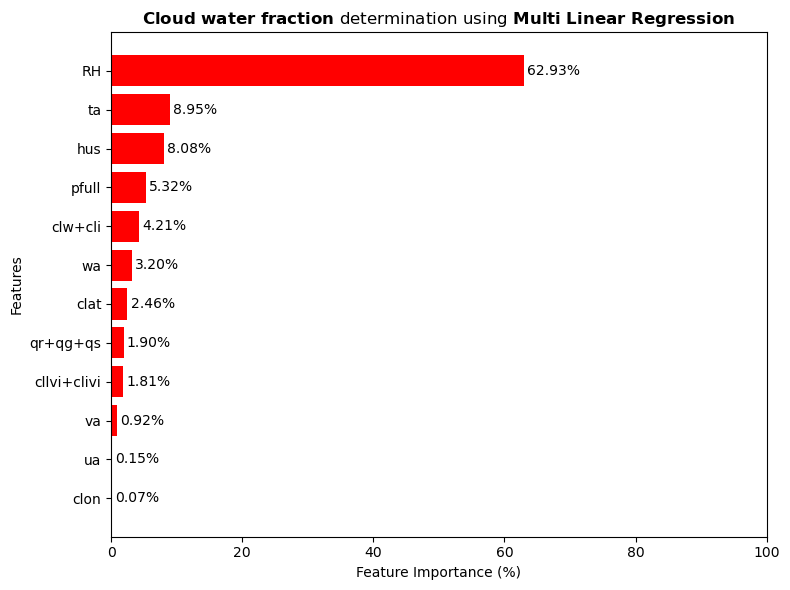

In [63]:
pairs = [(name, abs(coef)) for name, coef in zip(feature_names, coef_list)]
total = sum(c for _, c in pairs)

#Sort by importance (descending)
pairs.sort(key=lambda x: x[1], reverse=True)

names = []
importances = []

for name, coef in pairs:
    pct = (coef / total) * 100
    names.append(name)
    importances.append(pct)
    print(f"{name}: {pct:.4f} %")

#Bar plot
plt.figure(figsize=(8, 6))
bars = plt.barh(names, importances, color="red")

plt.xlabel("Feature Importance (%)")
plt.ylabel("Features")

#Modify title accordingly
plt.title(r"$\mathbf{Cloud\ water\ fraction}$ determination using $\mathbf{Multi\ Linear\ Regression}$")

# Highest importance at the top
plt.gca().invert_yaxis()

# Add percentage labels at the end of bars
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(
        width + 0.5,        #small space after the bar
        y,
        f"{width:.2f}%",
        va="center"
    )

plt.xlim(0, 100)
plt.tight_layout()
plt.show()


In [64]:
# import seaborn as sns

# plt.figure(figsize=(8,6))
# sns.scatterplot(x=y_test.flatten(), y=y_predicted.flatten(), alpha=0.7)
# plt.xlabel("Actual Values")
# plt.ylabel("Predicted Values")
# plt.title("Actual vs Predicted Values (MLR)")
# # Add a perfect prediction line
# plt.plot([y_test.min(), y_test.max()],
#          [y_test.min(), y_test.max()],
#          color='red', lw=2)
# plt.show()


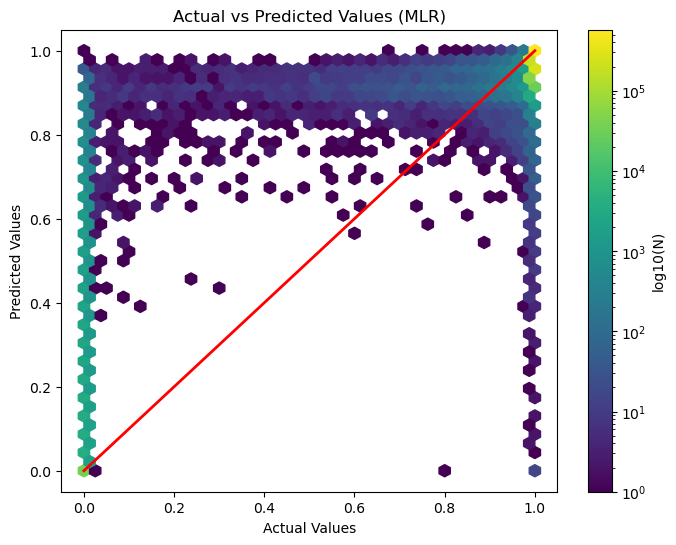

In [65]:
plt.figure(figsize=(8,6))
plt.hexbin(
    y_test.flatten(), 
    y_predicted.flatten(), 
    gridsize=40,  # smaller → finer grid
    cmap='viridis', 
    bins='log'  # logarithmic scaling helps emphasize dense areas
)
plt.colorbar(label='log10(N)')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', lw=2
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (MLR)")
plt.show()


In [66]:
##ft 16 ('RH') and -5 ('clw/(clw+cli)')
# df['RH']


In [67]:
df['clw/(clw+cli)']

0          0.0
1          1.0
2          1.0
3          1.0
4          1.0
          ... 
6026604    1.0
6026605    1.0
6026606    1.0
6026607    1.0
6026608    1.0
Name: clw/(clw+cli), Length: 6026609, dtype: float32

In [68]:
# plt.plot(df['RH'], df['clw/(clw+cli)']) #error in plotting probably because of huge size of data

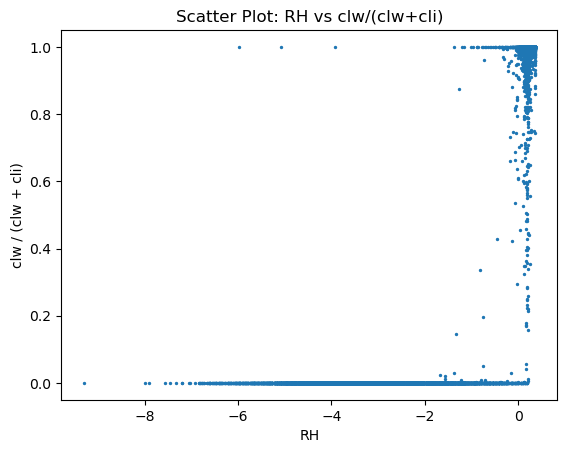

In [69]:
plt.scatter(df['RH'][::100], df['clw/(clw+cli)'][::100], s=2)
plt.xlabel("RH")
plt.ylabel("clw / (clw + cli)")
plt.title("Scatter Plot: RH vs clw/(clw+cli)")
plt.show()

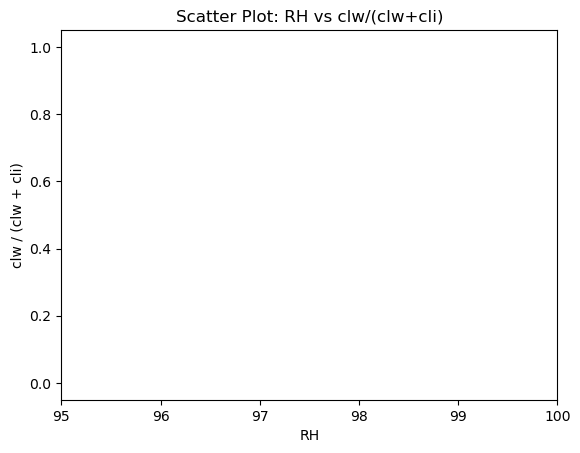

In [70]:
plt.scatter(df['RH'][::100], df['clw/(clw+cli)'][::100], s=2)
plt.xlim(95,100)
plt.xlabel("RH")
plt.ylabel("clw / (clw + cli)")
plt.title("Scatter Plot: RH vs clw/(clw+cli)")
plt.show()

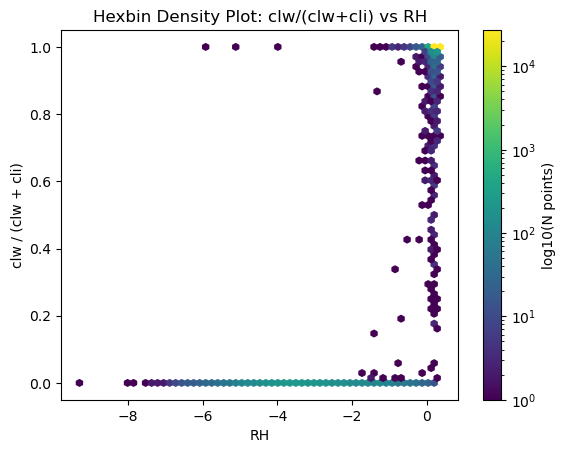

In [71]:
plt.hexbin(
    df['RH'][::100],
    df['clw/(clw+cli)'][::100],
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("RH")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: clw/(clw+cli) vs RH")
plt.show()


In [72]:
ds

<xarray.Dataset> Size: 73GB
Dimensions:    (ncells: 20971520, time: 1, height: 61, height_2: 61)
Coordinates:
  * time       (time) datetime64[ns] 8B 1979-01-12
  * height     (height) float64 488B 2.0 31.0 32.0 33.0 ... 87.0 88.0 89.0 90.0
  * height_2   (height_2) float64 488B 10.0 31.0 32.0 33.0 ... 88.0 89.0 90.0
    clon       (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
    clat       (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
Dimensions without coordinates: ncells
Data variables: (12/21)
    cell_area  (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
    pr         (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    tas        (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    clivi      (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    cllvi      (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    qgvi       (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    ...         ...
    wa         (time, height_2, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    rho        (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    dzghalf    (height, ncells) float32 5GB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    ua         (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    va         (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    pfull      (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
Attributes: (12/46)
    CDI:                      Climate Data Interface version 2.5.2.1 (https:/...
    Conventions:              CF-1.6
    number_of_grid_used:      55
    grid_file_uri:            http://icon-downloads.mpimet.mpg.de/grids/publi...
    uuidOfHGrid:              9a8d03ba-2027-11ef-a2ba-c74e1b4d7fe9
    institution:              Max Planck Institute for Meteorology/Deutscher ...
    ...                       ...
    topography:               modified SRTM30
    symmetry:                 along equator
    subcentre:                0
    ICON_grid_file_uri:       http://icon-downloads.mpimet.mpg.de/grids/publi...
    optimization:             spring dynamics
    NCO:                      netCDF Operators version 5.0.6 (Homepage = http...

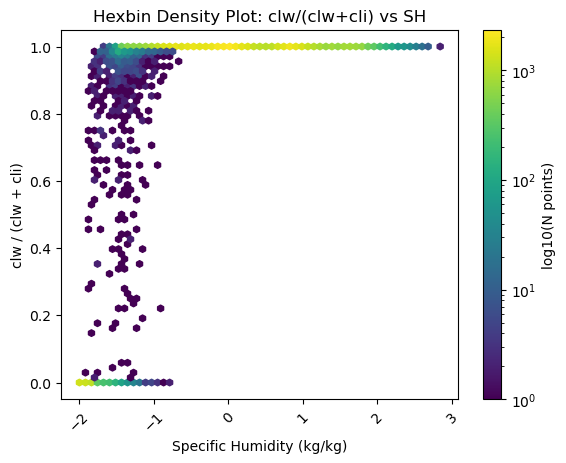

In [73]:
plt.hexbin(
    df['hus'][::100],
    df['clw/(clw+cli)'][::100],
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("Specific Humidity (kg/kg)")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: clw/(clw+cli) vs SH")

plt.xticks(rotation=45)   

plt.show()


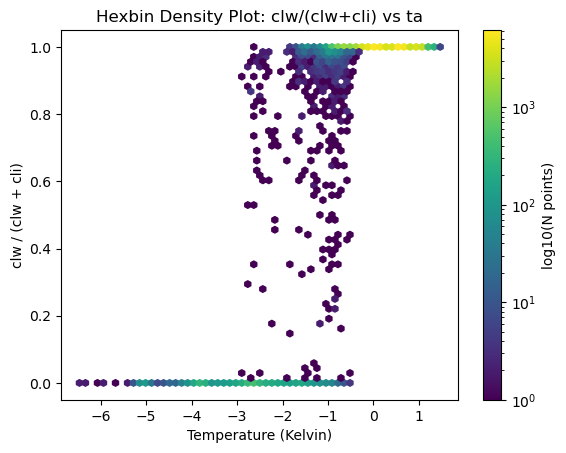

In [74]:
#clw frac v/s ta
plt.hexbin(
    df['ta'][::100],
    df['clw/(clw+cli)'][::100],
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("Temperature (Kelvin)")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: clw/(clw+cli) vs ta")
plt.show()


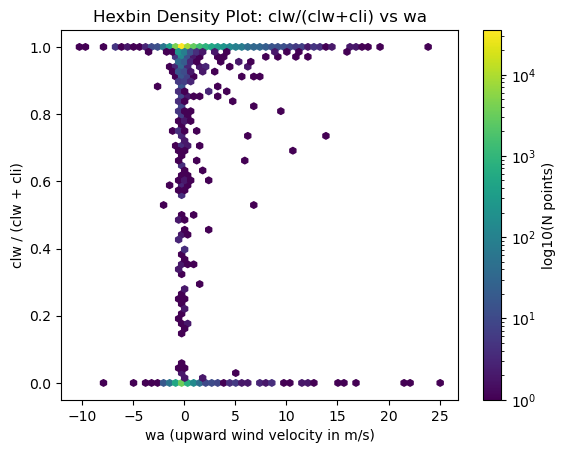

In [75]:
plt.hexbin(
    df['wa'][::100],
    df['clw/(clw+cli)'][::100],
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("wa (upward wind velocity in m/s)")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: clw/(clw+cli) vs wa")
plt.show()


In [76]:
ruko yaha

SyntaxError: invalid syntax (1197949976.py, line 1)

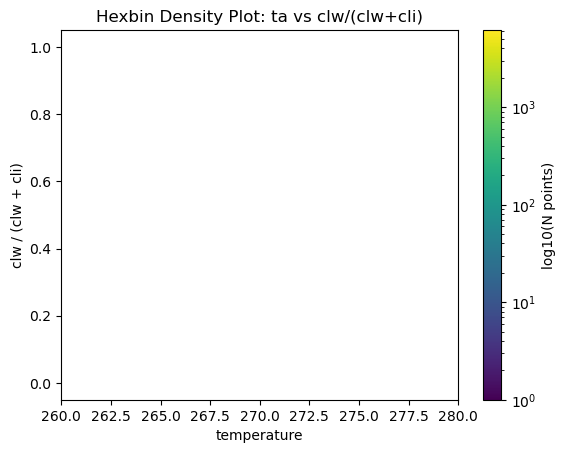

In [ ]:
#clw frac v/s ta
plt.hexbin(
    df['ta'][::100],
    df['clw/(clw+cli)'][::100],
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
plt.xlim(260, 280)
plt.xlabel("temperature")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: ta vs clw/(clw+cli)")
plt.show()


In [ ]:
# print("Description of the df:\n")
# print(df[['cli', 'clw', 'qr', 'qg', 'qs']].describe())
# print(df[['cli', 'clw', 'qr', 'qg', 'qs']].isna().sum())
# print("Description ends\n")

# split data into X and y
# X = df.iloc[:, [15,16]].values # RH, ta
X = df.iloc[:, [0,1,15,16,17,18,21,22,23,26,27,30]].values 

y = df.iloc[:, [-5]].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

cols= [0,1,15,16,17,18,21,22,23,26,27,30]
feature_names=df.columns[cols].tolist()
print(feature_names)

['clon', 'clat', 'hus', 'RH', 'ta', 'wa', 'ua', 'va', 'pfull', 'clw+cli', 'cllvi+clivi', 'qr+qg+qs']


In [ ]:
#This is df and not X_train
# print('RH min: ', df['RH'].min())
# print('RH max: ', df['RH'].max())
# print('\n')
print('ta min: ', df['ta'].min())
print('ta max: ', df['ta'].max())
print('\n')
print('pfull min: ', df['pfull'].min())
print('pfull max: ', df['pfull'].max())
print('\n')
print('wa min: ', df['wa'].min())
print('wa max: ', df['wa'].max())
print('\n')

ta min:  -6.831049380760118
ta max:  1.4883000115247098


pfull min:  -4.143600753922059
pfull max:  1.2986912719792705


wa min:  -13.040269827960126
wa max:  59.327256627639656




In [ ]:
print(len(y_train))
print(len(y_test))

4821287
1205322


Decision Tree

In [ ]:
# # #Medium
# # #Use Cross-Validation
# # #best depth acc. to val data

# train_r2_scores=[]
# val_r2_scores=[]
# depths=range(1,11) #This seemed a reasonable depth range which is obtained from trial and error and articles online
# for depth in depths:
#     tree=DTR(max_depth=depth, random_state=1)
#     #train
#     tree.fit(X_train,y_train)
#     train_score=tree.score(X_train, y_train)
#     train_r2_scores.append(train_score)
#     # print(f"Depth {depth}: Training R2 score = {train_score} ") 

#     #val
    
#     val_scores= cross_val_score(tree, X_train, y_train, cv=5, scoring='r2')
#     # print(f"Depth {depth}: Mean Validation R2 score = {val_scores.mean()} ") #val_scores.mean(): .4f
#     val_r2_scores.append(val_scores.mean())

# #print(type(val_scores)) #<class 'numpy.ndarray'>
# #print(val_scores)
# max_val_r2_score=max(val_r2_scores)
# bestDepth=depths[val_r2_scores.index(max_val_r2_score)]
# print(f"\nMax. Validation R2 score: {max_val_r2_score} is at depth (bestDepth): {bestDepth}") #Validation R2 score is different from Test R2 score

# #Plotting
# plt.figure() #figsize=(8,5)
# plt.plot(depths, train_r2_scores, marker='o', label='Training R2')
# plt.plot(depths, val_r2_scores, marker='s', label='Validation R2')
# plt.xlabel("Tree Depth")
# plt.ylabel("R2 score")
# plt.title("Decision Tree Performance vs Depth")
# plt.legend()
# plt.grid(True)
# plt.show()

# #time taken = 64 mins 51 seconds

In [ ]:
# #to find the best Depth and the best number of min samples in leaf
# depths = range(1, 11) #range(1, 21)
# min_samples_in_leaf = range(1, 41) #range(1,51)

# train_r2_scores = []
# val_r2_scores = []
# param_combinations = []

# best_val_score = -np.inf
# best_depth = None
# best_min_samples_leaf = None

# for depth in depths:
#     for min_samples in min_samples_in_leaf:
#         tree = DTR(max_depth=depth, min_samples_leaf=min_samples, random_state=1)

#         tree.fit(X_train, y_train)
#         train_score = tree.score(X_train, y_train)
      
#         val_scores = cross_val_score(tree, X_train, y_train, cv=5, scoring='r2')
#         val_mean = val_scores.mean()
       
#         train_r2_scores.append(train_score)
#         val_r2_scores.append(val_mean)
#         param_combinations.append((depth, min_samples))

#         if val_mean > best_val_score:
#             best_val_score = val_mean
#             best_depth = depth
#             best_min_samples_leaf = min_samples

# print(f"\nBest Validation R2 Score: {best_val_score: }")
# print(f"Best Parameters: max_depth={best_depth}, min_samples_leaf={best_min_samples_leaf}")

# #took 48 mins to run
# #eg: max_depth=14, min_samples_leaf=40

In [ ]:
# #Plot

# param_combinations = np.array(param_combinations)
# depths_arr = param_combinations[:, 0]
# min_samples_arr = param_combinations[:, 1]
# val_r2_scores = np.array(val_r2_scores)


# plt.figure(figsize=(10, 6))
# plt.tricontourf(depths_arr, min_samples_arr, val_r2_scores, levels=20, cmap='viridis')
# plt.colorbar(label="Mean CV (Validation) R2 Score")
# plt.xlabel("Tree Depth")
# plt.ylabel("Min Samples in Leaf")
# plt.title("Decision Tree Cross-Validation Performance Grid Search")
# plt.show()


Training- Elapsed time: 1.8187 minutes


[Text(0.2778962146422629, 0.9545454545454546, 'RH <= -0.109\nsquared_error = 0.074\nsamples = 4821287\nvalue = 0.919'),
 Text(0.12281613976705491, 0.8636363636363636, 'ta <= -0.614\nsquared_error = 0.012\nsamples = 386954\nvalue = 0.012'),
 Text(0.2003561772046589, 0.9090909090909092, 'True  '),
 Text(0.0834026622296173, 0.7727272727272727, 'RH <= -0.28\nsquared_error = 0.003\nsamples = 383464\nvalue = 0.004'),
 Text(0.04679700499168053, 0.6818181818181818, 'ta <= -0.844\nsquared_error = 0.001\nsamples = 379212\nvalue = 0.002'),
 Text(0.03036605657237937, 0.5909090909090909, 'qr+qg+qs <= -0.294\nsquared_error = 0.001\nsamples = 377818\nvalue = 0.001'),
 Text(0.02870216306156406, 0.5, 'squared_error = 0.247\nsamples = 31\nvalue = 0.451'),
 Text(0.032029950083194675, 0.5, 'RH <= -0.59\nsquared_error = 0.001\nsamples = 377787\nvalue = 0.001'),
 Text(0.018302828618968387, 0.4090909090909091, 'ta <= -0.957\nsquared_error = 0.0\nsamples = 370395\nvalue = 0.0'),
 Text(0.010815307820299502, 0.

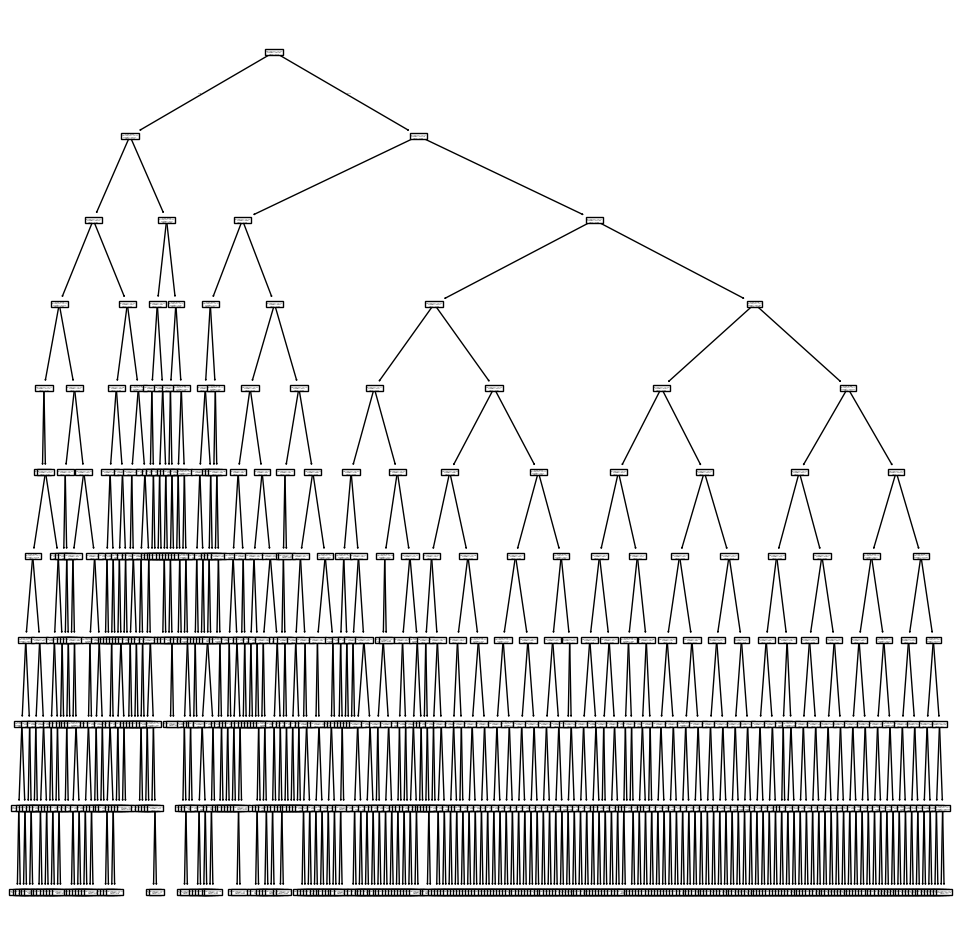

In [ ]:
#Pathway-1
best_depth= 10 #14
best_min_samples_leaf=30 #40

reg=DTR(max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, random_state=0)

##Training
training_start_time = time.time()
reg.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

ax=subplots(figsize=(12,12))[1]
plot_tree(reg, feature_names=feature_names, ax=ax)

In [ ]:
#Prediction
prediction_start_time = time.time()
y_pred = reg.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

Prediction- Elapsed time: 0.0010 minutes


In [ ]:
y_test=y_test.ravel()
y_pred=y_pred.ravel()

In [ ]:
#Error Analysis on TEST data
#MSE_test
mse_TEST= np.mean((y_test- y_pred)**2)
print(f'MSE_TEST: {mse_TEST}')

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')
# print(f'MSE_TEST: {(rmse_TEST)**2}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score before CCP:", r2_sklearn)

MSE_TEST: 0.000312904981420865
RMSE_TEST: 0.01768912042530281
mae_TEST: 0.0012446560379774448
R² score before CCP: 0.9957574532874637


In [ ]:
# #Pathway-1
# #This seems more robust because it uses CV and not test data to determine the best ccp_alpha

# ccp_path = reg.cost_complexity_pruning_path(X_train, y_train)

# kfold = skm.KFold(5,
# shuffle=True,
# random_state=10)

# grid = skm.GridSearchCV(reg,
# {'ccp_alpha': ccp_path.ccp_alphas},
# refit=True,
# cv=kfold,
# scoring='r2',
# n_jobs=-1)

# G = grid.fit(X_train, y_train)

# best_ = grid.best_estimator_
# print(best_)

# depth = best_.get_depth()
# print(depth)

In [ ]:
# #Pathway-1
# #Plot the best tree
# ax= subplots(figsize=(12,12))[1]
# plot_tree(G.best_estimator_, feature_names=feature_names, ax=ax) #after ccp

In [ ]:
# # ##Prediction
# prediction_start_time = time.time()
# y_pred = best_.predict(X_test)
# prediction_end_time = time.time()
# prediction_elapsed_time = prediction_end_time - prediction_start_time
# print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

# #########################################
# print('size of y_pred: ', len(y_pred))

In [ ]:
# #Comment this block if you do CCP

# ##Prediction
# prediction_start_time = time.time()
# y_pred = reg.predict(X_test)
# prediction_end_time = time.time()
# prediction_elapsed_time = prediction_end_time - prediction_start_time
# print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

# #########################################
# print('size of y_pred: ', len(y_pred))

In [ ]:
# #Error Analysis on TEST data
# #MSE_test
# mse_TEST= np.mean((y_test- y_pred)**2)
# print(f'MSE_TEST: {mse_TEST}')

# #rmse_test
# rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
# print(f'RMSE_TEST: {rmse_TEST}')
# # print(f'MSE_TEST: {(rmse_TEST)**2}')

# #mae_TEST
# mae_TEST = np.mean(abs(y_test - y_pred))
# print(f'mae_TEST: {mae_TEST}')

# #R2_test_sklearn
# r2_sklearn = r2_score(y_test, y_pred)
# print("R² score:", r2_sklearn)

RH:97.9733 %
ta:1.0879 %
clw+cli:0.5948 %
qr+qg+qs:0.2317 %
hus:0.0440 %
pfull:0.0295 %
wa:0.0230 %
clat:0.0078 %
cllvi+clivi:0.0048 %
clon:0.0016 %
ua:0.0010 %
va:0.0006 %


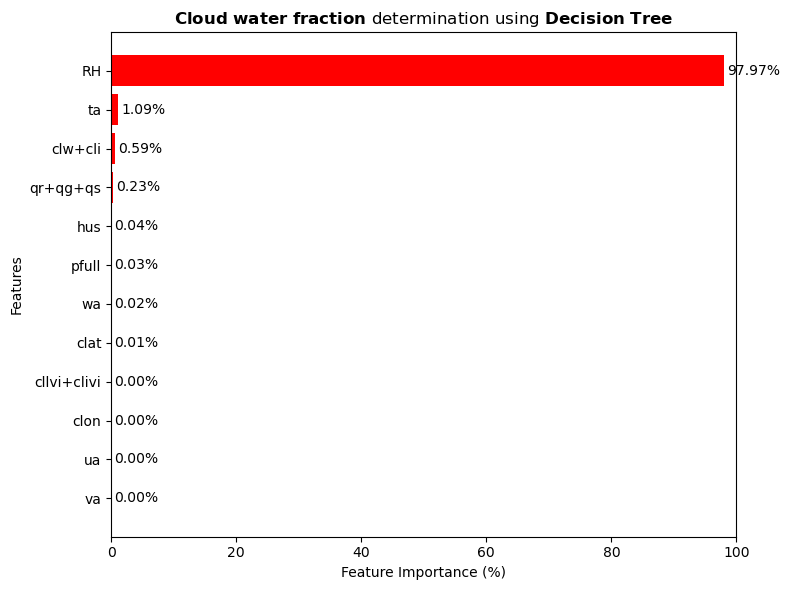

In [ ]:
import matplotlib.pyplot as plt

# Your existing logic
importance = reg.feature_importances_
feature_scores = list(zip(feature_names, importance))
feature_scores.sort(key=lambda x: x[1], reverse=True)

# Convert to percentages
names = []
importances = []

for name, score in feature_scores:
    pct = score * 100
    names.append(name)
    importances.append(pct)
    print(f'{name}:{pct:.4f} %')

# ---- Bar plot ----
plt.figure(figsize=(8, 6))
bars = plt.barh(names, importances, color="red")

plt.xlabel("Feature Importance (%)")
plt.ylabel("Features")
plt.title(r"$\mathbf{Cloud\ water\ fraction}$ determination using $\mathbf{Decision\ Tree}$")


# Highest importance at the top
plt.gca().invert_yaxis()

# Add percentage labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(
        width + 0.5,   # small space after bar
        y,
        f"{width:.2f}%",
        va="center"
    )

# Set x-axis from 0 to 100
plt.xlim(0, 100)

plt.tight_layout()
plt.show()


In [ ]:
# best_ccp_alpha= best_.ccp_alpha
# best_ccp_alpha

Bagging

In [ ]:
#expt with min_sample_leaf = 50, etc. 

In [ ]:
# #for loop to see at what n_estimators the validation error converges

# X_train_sub, X_val, y_train_sub, y_val=train_test_split(X_train, y_train, test_size=0.2, random_state=1)

# prev_validation_r2_score=0 #Initialized arbitrarily to 0 to run the first tree in the for loop 
# diff=1 # difference between R2 scores of the previous and the current tree. Initialized arbitrarily to 1 to run the first tree in the for loop 
# upper_bound_n_trees=201
# x_axis= range(1,upper_bound_n_trees)
# threshold= 1E-7 ###1E-7
# train_sub_r2_scores=[]
# validation_r2_scores=[]
# for n_trees in x_axis:
        
#         # print("Diff= ", diff)
#         if(diff<threshold):
#                 print(f"Converged at {n_trees-1} trees")
#                 ideal_n_trees= n_trees-1
#                 break


#         #Bagging
#         model = RandomForestRegressor(n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf ,n_estimators=n_trees, oob_score=True) #can set verbose=2 to see the steps 

#         ##Training
#         model.fit(X_train_sub, y_train_sub)

#         train_sub_r2= model.score(X_train_sub, y_train_sub)
#         validation_r2 = model.score(X_val, y_val)

#         train_sub_r2_scores.append(train_sub_r2)
#         validation_r2_scores.append(validation_r2)

#         diff= abs(validation_r2 - prev_validation_r2_score)
#         prev_validation_r2_score=validation_r2

# n_trees_for_which_max_r2 = x_axis[validation_r2_scores.index(max(validation_r2_scores))]


# print(f"Best number of trees (based on validation data): {n_trees_for_which_max_r2}")
# print(f"Best validation R² score: {max(validation_r2_scores)}")

# if(diff>=threshold):
#                 ideal_n_trees= upper_bound_n_trees-1

# plt.figure(figsize=(8,5))
# plt.plot(range(1, len(train_sub_r2_scores)+1 ), train_sub_r2_scores, marker='o', label='Training R2')
# plt.plot(range(1, len(validation_r2_scores)+1 ), validation_r2_scores, marker='s', label='Validation R2')
# plt.xlabel('Number of Trees')
# plt.ylabel('R2 Score')
# plt.title('R2 score vs number of trees')
# plt.legend()
# plt.grid(True)
# plt.show()


In [ ]:
#Bagging
ideal_n_trees=100
model = RandomForestRegressor(n_jobs=-1, random_state=0, max_depth=best_depth, n_estimators=ideal_n_trees, oob_score=True, min_samples_leaf=best_min_samples_leaf) #can set verbose=2 to see the steps 

##Training
training_start_time = time.time()
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_pred = model.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")
 

#Error Analysis on TEST data
#MSE_test
MSE_Test = np.mean((y_test - y_pred)**2)
print(f'MSE_Test: {MSE_Test}')

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score (sklearn):", r2_sklearn)

Training- Elapsed time: 7.6804 minutes
Prediction- Elapsed time: 0.0088 minutes
MSE_Test: 0.00026679526753424883
RMSE_TEST: 0.0163338687252668
mae_TEST: 0.001196663562906733
R² score (sklearn): 0.9963826354567514


In [ ]:
#Bagging ft. importance in descending order
#Sort indices by importance
sorted_idx = np.argsort(model.feature_importances_)[::-1]

#print("\nAll features sorted by importance:")
for i in sorted_idx:
    pct=model.feature_importances_[i] * 100
    print(f"{feature_names[i]}: {pct:.4f} %")

RH: 97.9915 %
ta: 1.0832 %
clw+cli: 0.5689 %
qr+qg+qs: 0.2447 %
hus: 0.0440 %
pfull: 0.0267 %
wa: 0.0237 %
clat: 0.0098 %
cllvi+clivi: 0.0044 %
clon: 0.0015 %
ua: 0.0010 %
va: 0.0005 %


RH: 97.9915 %
ta: 1.0832 %
clw+cli: 0.5689 %
qr+qg+qs: 0.2447 %
hus: 0.0440 %
pfull: 0.0267 %
wa: 0.0237 %
clat: 0.0098 %
cllvi+clivi: 0.0044 %
clon: 0.0015 %
ua: 0.0010 %
va: 0.0005 %


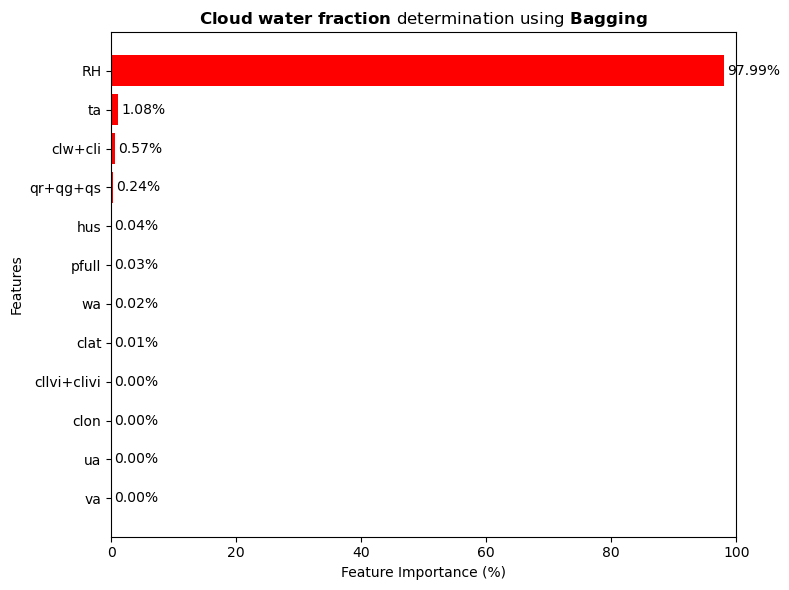

In [ ]:
sorted_idx = np.argsort(model.feature_importances_)[::-1]

names = []
importances = []

for i in sorted_idx:
    pct = model.feature_importances_[i] * 100
    names.append(feature_names[i])
    importances.append(pct)
    print(f"{feature_names[i]}: {pct:.4f} %")

# ---- Bar plot ----
plt.figure(figsize=(8, 6))
bars = plt.barh(names, importances, color="red")

plt.xlabel("Feature Importance (%)")
plt.ylabel("Features")
plt.title(r"$\mathbf{Cloud\ water\ fraction}$ determination using $\mathbf{Bagging}$")

# Highest importance at the top
plt.gca().invert_yaxis()

# Add percentage labels at the end of bars
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(
        width + 0.5,
        y,
        f"{width:.2f}%",
        va="center"
    )

# Set x-axis from 0 to 100
plt.xlim(0, 100)

plt.tight_layout()
plt.show()


In [ ]:
# # Bagging with CCP

# ideal_n_trees=100
# #I am using the best_ccp_alpha I got from a single Decision Tree using CV
# model = RandomForestRegressor(ccp_alpha=best_ccp_alpha, n_jobs=-1, random_state=0, max_depth=best_depth, n_estimators=ideal_n_trees, oob_score=True, min_samples_leaf=best_min_samples_leaf) #can set verbose=2 to see the steps 

# ##Training
# training_start_time = time.time()
# model.fit(X_train, y_train)
# training_end_time = time.time()
# training_elapsed_time = training_end_time - training_start_time
# print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

# ##Prediction
# prediction_start_time = time.time()
# y_pred = model.predict(X_test)
# prediction_end_time = time.time()
# prediction_elapsed_time = prediction_end_time - prediction_start_time
# print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")
 

# #Error Analysis on TEST data
# #MSE_test
# MSE_Test = np.mean((y_test - y_pred)**2)
# print(f'MSE_Test: {MSE_Test}')

# #rmse_test
# rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
# print(f'RMSE_TEST: {rmse_TEST}')

# #mae_TEST
# mae_TEST = np.mean(abs(y_test - y_pred))
# print(f'mae_TEST: {mae_TEST}')

# #R2_test_sklearn
# r2_sklearn = r2_score(y_test, y_pred)
# print("R² score (sklearn):", r2_sklearn)


In [ ]:
# #Bagging ft. importance in descending order
# #Sort indices by importance
# sorted_idx = np.argsort(model.feature_importances_)[::-1]

# #print("\nAll features sorted by importance:")
# for i in sorted_idx:
#     print(f"{feature_names[i]}: {model.feature_importances_[i]:.4f}")

Random Forest

#Bagging Code 2

Random Forest

In [ ]:
# #ideal num of trees for Random Forest
# #for loop to see at what n_estimators the validation error converges

# X_train_sub, X_val, y_train_sub, y_val=train_test_split(X_train, y_train, test_size=0.2, random_state=1)

# prev_validation_r2_score=0 #Initialized arbitrarily to 0 to run the first tree in the for loop 
# diff=1 # difference between R2 scores of the previous and the current tree. Initialized arbitrarily to 1 to run the first tree in the for loop 
# upper_bound_n_trees=201
# x_axis= range(1,upper_bound_n_trees)
# threshold= 1E-7 #1E-7
# train_sub_r2_scores=[]
# validation_r2_scores=[]
# for n_trees in x_axis:
        
#         # print("Diff= ", diff)
#         if(diff<threshold):
#                 print(f"Converged at {n_trees-1} trees")
#                 ideal_n_trees= n_trees-1
#                 break


#         #Bagging
#         model = RandomForestRegressor(n_jobs=-1, random_state=0, max_features=int(np.sqrt(X_train.shape[1])), max_depth=best_depth, min_samples_leaf=best_min_samples_leaf ,n_estimators=n_trees, oob_score=True) #can set verbose=2 to see the steps 

#         ##Training
#         model.fit(X_train_sub, y_train_sub)

#         train_sub_r2= model.score(X_train_sub, y_train_sub)
#         validation_r2 = model.score(X_val, y_val)

#         train_sub_r2_scores.append(train_sub_r2)
#         validation_r2_scores.append(validation_r2)

#         diff= abs(validation_r2 - prev_validation_r2_score)
#         prev_validation_r2_score=validation_r2

# n_trees_for_which_max_r2 = x_axis[validation_r2_scores.index(max(validation_r2_scores))]


# print(f"Best number of trees (based on validation data): {n_trees_for_which_max_r2}")
# print(f"Best validation R² score: {max(validation_r2_scores)}")

# if(diff>=threshold):
#                 ideal_n_trees= upper_bound_n_trees-1

# plt.figure(figsize=(8,5))
# plt.plot(range(1, len(train_sub_r2_scores)+1 ), train_sub_r2_scores, marker='o', label='Training R2')
# plt.plot(range(1, len(validation_r2_scores)+1 ), validation_r2_scores, marker='s', label='Validation R2')
# plt.xlabel('Number of Trees')
# plt.ylabel('R2 Score')
# plt.title('R2 score vs number of trees')
# plt.legend()
# plt.grid(True)
# plt.show()


In [ ]:
#Random Forest
##Training
ideal_n_trees=100

training_start_time = time.time()
RF_condensates = RandomForestRegressor(n_estimators=ideal_n_trees, max_features=int(np.sqrt(X_train.shape[1])), n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, oob_score=True).fit(X_train, y_train)
#RF_condensates = RandomForestRegressor(n_estimators=ideal_n_trees, max_features=int( np.floor(0.75 * X_train.shape[1])), n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, oob_score=True).fit(X_train, y_train)
# RF_condensates = RF(n_estimators=200, max_features=int(np.sqrt(X_train.shape[1])), n_jobs=-1, random_state=0, oob_score=True).fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_hat_RF = RF_condensates.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

print("max: ", np.max(y_hat_RF))
print("min: ", np.min(y_hat_RF))

Training- Elapsed time: 2.5246 minutes
Prediction- Elapsed time: 0.0055 minutes
max:  0.9999923800038008
min:  6.159996373180038e-05


In [ ]:
int( np.floor(0.75 * X_train.shape[1]))

9

In [ ]:
int(np.sqrt(X_train.shape[1]))

3

In [ ]:
RF_condensates

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,30
,min_weight_fraction_leaf,0.0
,max_features,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [ ]:
# List of depths for all trees
tree_depths = [estimator.tree_.max_depth for estimator in RF_condensates.estimators_]

# Average, min, and max depth across the forest
print("Average depth:", sum(tree_depths) / len(tree_depths))
print("Min depth:", min(tree_depths))
print("Max depth:", max(tree_depths))


Average depth: 10.0
Min depth: 10
Max depth: 10


In [ ]:
#Error Analysis on TEST data
#mse_Test
mse= np.mean((y_test- y_hat_RF)**2)
print('MSE: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_hat_RF)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_hat_RF))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_hat_RF)
print("R² score: ", r2_sklearn) 

MSE:  0.0003054837957291326
RMSE_TEST: 0.017478094739677222
mae_TEST: 0.001634787433799618
R² score:  0.9958580740152533


RH: 31.3968 %
hus: 22.3018 %
ta: 19.8506 %
pfull: 13.5687 %
clw+cli: 9.2055 %
cllvi+clivi: 1.5733 %
clat: 0.8579 %
qr+qg+qs: 0.6591 %
ua: 0.4215 %
wa: 0.1158 %
va: 0.0280 %
clon: 0.0210 %


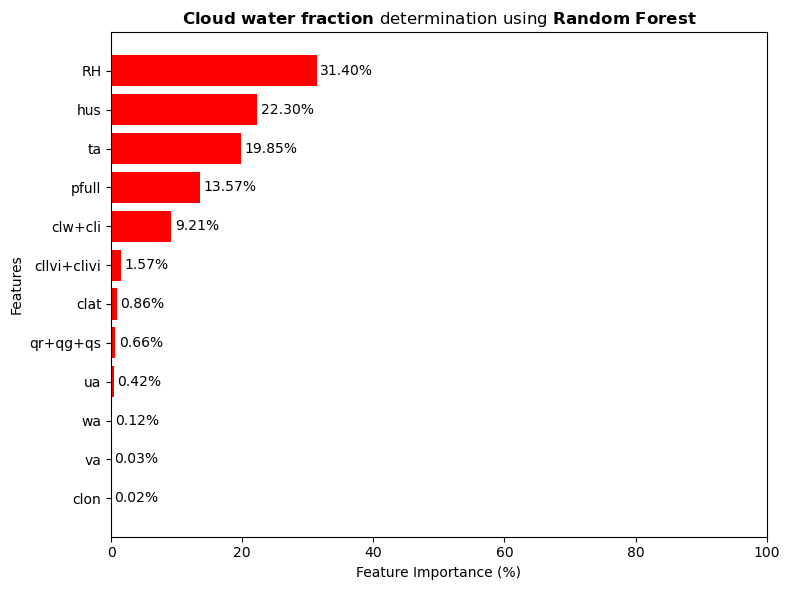

In [ ]:
importance = RF_condensates.feature_importances_

# Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

# Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

# Convert to percentages
names = []
importances = []

for name, score in feature_scores:
    pct = score * 100
    names.append(name)
    importances.append(pct)
    print(f"{name}: {pct:.4f} %")

# ---- Bar plot ----
plt.figure(figsize=(8, 6))
bars = plt.barh(names, importances, color="red")

plt.xlabel("Feature Importance (%)")
plt.ylabel("Features")
plt.title(r"$\mathbf{Cloud\ water\ fraction}$ determination using $\mathbf{Random\ Forest}$")

# Highest importance at the top
plt.gca().invert_yaxis()

# Add percentage labels at the end of the bars
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(
        width + 0.5,
        y,
        f"{width:.2f}%",
        va="center"
    )

# Set x-axis range from 0 to 100
plt.xlim(0, 100)

plt.tight_layout()
plt.show()


In [ ]:
# #Random Forest with CCP

# ##Training
# ideal_n_trees=100

# training_start_time = time.time()
# RF_condensates = RandomForestRegressor(ccp_alpha= best_ccp_alpha, n_estimators=ideal_n_trees, max_features=int(np.sqrt(X_train.shape[1])), n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, oob_score=True).fit(X_train, y_train)
# #RF_condensates = RandomForestRegressor(n_estimators=ideal_n_trees, max_features=int( np.floor(0.75 * X_train.shape[1])), n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, oob_score=True).fit(X_train, y_train)
# # RF_condensates = RF(n_estimators=200, max_features=int(np.sqrt(X_train.shape[1])), n_jobs=-1, random_state=0, oob_score=True).fit(X_train, y_train)
# training_end_time = time.time()
# training_elapsed_time = training_end_time - training_start_time
# print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

# ##Prediction
# prediction_start_time = time.time()
# y_hat_RF = RF_condensates.predict(X_test)
# prediction_end_time = time.time()
# prediction_elapsed_time = prediction_end_time - prediction_start_time
# print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

# print("max: ", np.max(y_hat_RF))
# print("min: ", np.min(y_hat_RF))

# #Error Analysis on TEST data
# #mse_Test
# mse= np.mean((y_test- y_hat_RF)**2)
# print('MSE: ', mse)

# #rmse_test
# rmse_TEST = np.sqrt(np.mean((y_test - y_hat_RF)**2))
# print(f'RMSE_TEST: {rmse_TEST}')

# #mae_TEST
# mae_TEST = np.mean(abs(y_test - y_hat_RF))
# print(f'mae_TEST: {mae_TEST}')

# #R2_test_sklearn
# r2_sklearn = r2_score(y_test, y_hat_RF)
# print("R² score: ", r2_sklearn) #old value: 0.9922993421321149

In [ ]:
# #RF Ft. importance in descending order
# importance = RF_condensates.feature_importances_

# #Combine ft. names and scores
# feature_scores = list(zip(feature_names, importance))

# #Sort by score in descending order
# feature_scores.sort(key=lambda x: x[1], reverse=True)

# for name, score in feature_scores:
#     print(f'{name}:{score:.6f}')

Boosting

In [ ]:
#Method 1: Using GridSearchCV
# from sklearn.model_selection import GridSearchCV

# param_grid ={
#     'n_estimators':[100,200],
#     'learning_rate':[0.01, 0.1, 0.5],
#     'max_depth': [5,7,10,12], #add more depths later
#     'min_samples_leaf' :[10, 30] 
# }

# gb_model= GBR()

# grid_search= GridSearchCV(estimator=gb_model, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)

# grid_search.fit(X_train, y_train)

# best_params = grid_search.best_params_
# best_model = grid_search.best_estimator_

# y_pred_best = best_model.predict(X_test)

# r2_best = r2_score(y_test, y_pred_best)

# print('Best parameters: ', best_params)
# print(f'Best Model R2 score: {r2_best}')


In [ ]:
#Method 2: Best hyperparameters using RandomizedSeachCV

# from sklearn.model_selection import RandomizedSearchCV

# param_dist ={
#     'n_estimators':[100,200],
#     'learning_rate': np.arange(0.01,0.1, 0.5),
#     'max_depth': [5,7,10,12], #add more depths later
#     'min_samples_leaf' :[10, 30] 
# }

# gb_model = GBR()

# random_search= RandomizedSearchCV(estimator=gb_model, param_distributions=param_dist, n_iter=10, cv=5, scoring='r2', n_jobs=-1)

# random_search.fit(X_train, y_train)

# best_params= random_search.best_params_
# best_model= random_search.best_estimator_

# y_pred_best= best_model.predict(X_test)
# r2_best = r2_score(y_test, y_pred_best)

# print("Best parameters: ", best_params)
# print(f"Best Model R2 Score: {r2_best}")

In [ ]:
# #Use this block-1

# #Use grid search's best parameters!
# best_n_trees=100 #best_params['n_estimators']
# best_min_samples_leaf=30 #best_params['min_samples_leaf']
# best_max_depth=10 #best_params['max_depth']
# best_learning_rate= 0.1 #best_params['learning_rate']

In [ ]:
# #Use this block-2

# #Boosting
# boost_condensates=GBR(random_state=0, n_estimators=best_n_trees, learning_rate=best_learning_rate, min_samples_leaf=best_min_samples_leaf, max_depth=best_max_depth)

# ##Training
# training_start_time = time.time()
# boost_condensates.fit(X_train, y_train)
# training_end_time = time.time()
# training_elapsed_time = training_end_time - training_start_time
# print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes") #73 mins and countiung, then disconnected.
# #Total elapsed time: 163.8 mins

In [ ]:
# #Use this block

# #x axis: boosting iteration number
# test_error = np.zeros_like(boost_condensates.train_score_)
# for idx, y_ in enumerate(boost_condensates.staged_predict(X_test)):
#     ######################################################
#     #####################################################
#     count=0
#     for i in y_:
#         if i>1 or i<0:
#             # print(i)
#             count+=1
#     print(f"Iteration {idx} incorrect count = ", count)
#     print("incorrect count percent = ", 100*count/len(y_))
#     #####################################################
#     y_ = np.clip(y_, 0, 1)
#     ######################################################
#     test_error[idx] = np.mean((y_test- y_)**2)
# plot_idx = np.arange(boost_condensates.train_score_.shape[0])
# ax = subplots(figsize=(8,8))[1]
# ax.plot(plot_idx,
# boost_condensates.train_score_,
# 'b',
# label='Training')

# ax.plot(plot_idx,
# test_error,
# 'r',
# label='Test')
# ax.legend();

# ax.set_xlabel("Total number of trees")
# ax.set_ylabel("Mean Squared Error")

# # print("Shape:", boost_condensates.train_score_.shape) #iterations
# # print("Number of elements:", boost_condensates.train_score_.size)

In [ ]:
# #Use this block-3

# ##Prediction
# prediction_start_time = time.time()
# y_hat_boost = boost_condensates.predict(X_test);
# prediction_end_time = time.time()
# prediction_elapsed_time = prediction_end_time - prediction_start_time
# print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

# y_hat_boost = np.clip(y_hat_boost, 0, 1)
# #Error Analysis on TEST data
# #mse_test
# mse= np.mean((y_test- y_hat_boost)**2)
# print('MSE_Test: ', mse)

# #rmse_test
# rmse_TEST = np.sqrt(np.mean((y_test - y_hat_boost)**2))
# print(f'RMSE_TEST: {rmse_TEST}')

# #mae_TEST
# mae_TEST = np.mean(abs(y_test - y_hat_boost))
# print(f'mae_TEST: {mae_TEST}')

# #R2_test_sklearn
# r2_sklearn = r2_score(y_test, y_hat_boost)
# print("R² score: ", r2_sklearn)

In [ ]:
# #Use this block-4

# #Boosting ft. importance in descending order
# importance = boost_condensates.feature_importances_

# #Combine ft. names and scores
# feature_scores = list(zip(feature_names, importance))

# #Sort by score in descending order
# feature_scores.sort(key=lambda x: x[1], reverse=True)

# for name, score in feature_scores:
#     print(f'{name}:{score:.6f}')

In [ ]:
# #Boosting with CCP

# best_n_trees=100 #best_params['n_estimators']
# best_min_samples_leaf=30 #best_params['min_samples_leaf']
# best_max_depth=12 #best_params['max_depth']
# best_learning_rate= 0.1 #best_params['learning_rate']

# #Boosting
# boost_condensates=GBR(ccp_alpha=best_ccp_alpha, random_state=0, n_estimators=best_n_trees, learning_rate=best_learning_rate, min_samples_leaf=best_min_samples_leaf, max_depth=best_max_depth)

# ##Training
# training_start_time = time.time()
# boost_condensates.fit(X_train, y_train)
# training_end_time = time.time()
# training_elapsed_time = training_end_time - training_start_time
# print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes") #73 mins and countiung, then disconnected.

# #Training- Elapsed time: 150.0770 minutes (compute node)
# #Training- Elapsed time:  minutes (interactive node)

In [ ]:
# #x axis: boosting iteration number
# test_error = np.zeros_like(boost_condensates.train_score_)
# for idx, y_ in enumerate(boost_condensates.staged_predict(X_test)):
#     ######################################################
#     #####################################################
#     count=0
#     for i in y_:
#         if i>1 or i<0:
#             # print(i)
#             count+=1
#     print(f"Iteration {idx} incorrect count = ", count)
#     print("incorrect count percent = ", 100*count/len(y_))
#     #####################################################
#     y_ = np.clip(y_, 0, 1)
#     ######################################################
#     test_error[idx] = np.mean((y_test- y_)**2)
# plot_idx = np.arange(boost_condensates.train_score_.shape[0])
# ax = subplots(figsize=(8,8))[1]
# ax.plot(plot_idx,
# boost_condensates.train_score_,
# 'b',
# label='Training')

# ax.plot(plot_idx,
# test_error,
# 'r',
# label='Test')
# ax.legend();

# ax.set_xlabel("Total number of trees")
# ax.set_ylabel("Mean Squared Error")


# # print("Shape:", boost_condensates.train_score_.shape) #iterations
# # print("Number of elements:", boost_condensates.train_score_.size)

In [ ]:
# ##Prediction
# prediction_start_time = time.time()
# y_hat_boost = boost_condensates.predict(X_test);
# prediction_end_time = time.time()
# prediction_elapsed_time = prediction_end_time - prediction_start_time
# print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

# y_hat_boost = np.clip(y_hat_boost, 0, 1)
# #Error Analysis on TEST data
# #mse_test
# mse= np.mean((y_test- y_hat_boost)**2)
# print('MSE_Test: ', mse)

# #rmse_test
# rmse_TEST = np.sqrt(np.mean((y_test - y_hat_boost)**2))
# print(f'RMSE_TEST: {rmse_TEST}')

# #mae_TEST
# mae_TEST = np.mean(abs(y_test - y_hat_boost))
# print(f'mae_TEST: {mae_TEST}')

# #R2_test_sklearn
# r2_sklearn = r2_score(y_test, y_hat_boost)
# print("R² score: ", r2_sklearn)

In [ ]:
# #Boosting ft. importance in descending order
# importance = boost_condensates.feature_importances_

# #Combine ft. names and scores
# feature_scores = list(zip(feature_names, importance))

# #Sort by score in descending order
# feature_scores.sort(key=lambda x: x[1], reverse=True)

# for name, score in feature_scores:
#     print(f'{name}:{score:.6f}')

XGBoost

In [ ]:
# #Method 1: Grid Search
# from sklearn.model_selection import GridSearchCV

# param_grid={
#     'n_estimators': [100, 200],
#     'max_depth': [5, 7, 10, 12],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'min_child_weight': [10, 30]
# }


# xgb_model= xgb.XGBRegressor()

# grid_search= GridSearchCV(xgb_model, param_grid, cv=5, scoring='r2')


# grid_search.fit(X_train, y_train)

# print("Best set of hyperparameters: ", grid_search.best_params_)
# print("Best score: ", grid_search.best_score_)


In [ ]:
# #n_estimators, eta/learning_rate, max_depth, min_child_weight?, max_bin (def=256)->increasing this number improves the optimality of splits at the cost of higher computation time.
# #Method 2: Random Search
# import scipy.stats as stats

# param_dist = {
#     'n_estimators': stats.randint(100, 201),
#     'max_depth': stats.randint(5,13),
#     'learning_rate': stats.uniform(0.01, 0.2),
#     'min_child_weight': stats.randint(10, 31)
#     }

# model = XGBRegressor()

# # Set up the random search with 4-fold cross validation
# random_cv = RandomizedSearchCV(random_state=1, estimator=model, param_distributions= param_dist, cv=5, n_iter=100, scoring='r2', n_jobs=-1, return_train_score= True)  #verbose=5

# random_cv.fit(X_train, y_train)

# print("Best set of hyperparameters: ", random_cv.best_params_)
# print("Best score: ", random_cv.best_score_)

In [ ]:
#random_cv.best_estimator_

In [ ]:
# best_parameters= grid_search.best_params_

best_n_estimators=100 #best_parameters['n_estimators']
best_min_child_weight=30 #best_parameters['min_child_weight']
best_max_depth=10 #best_parameters['max_depth']
best_learning_rate=0.1 #best_parameters['learning_rate']

In [ ]:
#XGBoost

# fit model
model = XGBRegressor(n_estimators=best_n_estimators, min_child_weight= best_min_child_weight, max_depth=best_max_depth, learning_rate=best_learning_rate, n_jobs=-1, random_state=0) #verbosity=3 (optional)

##Training
training_start_time = time.time()
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_pred = model.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

Training- Elapsed time: 0.2006 minutes
Prediction- Elapsed time: 0.0020 minutes


In [ ]:
print("max: ", np.max(y_pred))
print("min: ", np.min(y_pred))

max:  1.3514185
min:  -0.13505322


In [ ]:
# count=0
# for i in y_pred:
#     if i>1 or i<0:
#         # print(i)
#         count+=1
# print("incorrect count = ", count)
# print("incorrect count percent = ", 100*count/len(y_pred))

In [ ]:
y_pred = np.clip(y_pred, 0, 1)

In [ ]:
y_test=y_test.ravel()
y_pred=y_pred.ravel()

In [ ]:
#Error Analysis on TEST data
#mse
mse= np.mean((y_test- y_pred)**2)
print('MSE_Test: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score: ", r2_sklearn)

MSE_Test:  0.00018331825
RMSE_TEST: 0.013539507053792477
mae_TEST: 0.0009461730951443315
R² score:  0.9975144863128662


In [ ]:
#xgb feature importance
importance = model.feature_importances_

#Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

for name, score in feature_scores:
    print(f'{name}:{score:.6f}')

RH:0.983799
ta:0.007813
clw+cli:0.004577
qr+qg+qs:0.001268
hus:0.000661
wa:0.000487
pfull:0.000374
clat:0.000296
cllvi+clivi:0.000261
clon:0.000162
ua:0.000160
va:0.000144


RH: 98.3799 %
ta: 0.7813 %
clw+cli: 0.4577 %
qr+qg+qs: 0.1268 %
hus: 0.0661 %
wa: 0.0487 %
pfull: 0.0374 %
clat: 0.0296 %
cllvi+clivi: 0.0261 %
clon: 0.0162 %
ua: 0.0160 %
va: 0.0144 %


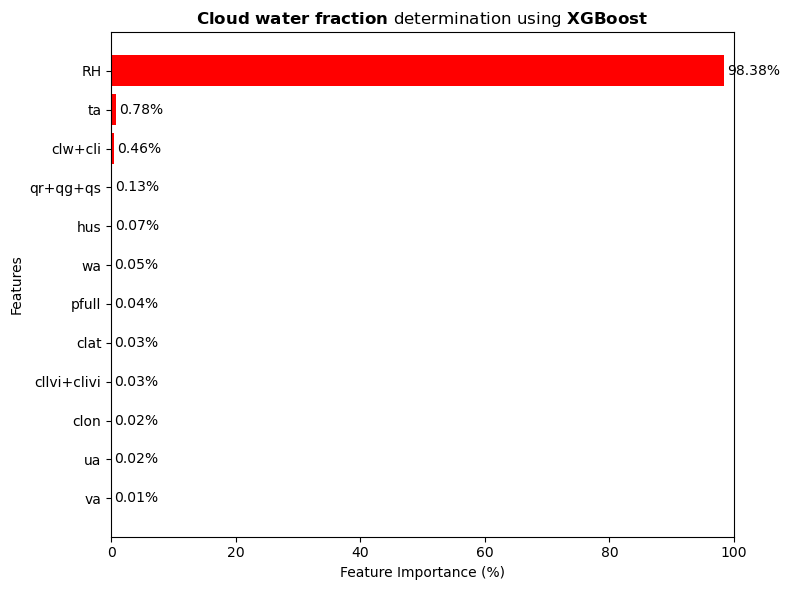

In [ ]:
import matplotlib.pyplot as plt

# ---- Your existing logic ----
importance = model.feature_importances_

# Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

# Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

# Convert to percentages
names = []
importances = []

for name, score in feature_scores:
    pct = score * 100
    names.append(name)
    importances.append(pct)
    print(f"{name}: {pct:.4f} %")

# ---- Bar plot ----
plt.figure(figsize=(8, 6))
bars = plt.barh(names, importances, color="red")

plt.xlabel("Feature Importance (%)")
plt.ylabel("Features")
plt.title(r"$\mathbf{Cloud\ water\ fraction}$ determination using $\mathbf{XGBoost}$")

# Highest importance at the top
plt.gca().invert_yaxis()

# Add percentage labels
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(
        width + 0.5,
        y,
        f"{width:.2f}%",
        va="center"
    )

# Set x-axis range
plt.xlim(0, 100)

plt.tight_layout()
plt.show()


In [ ]:
# plt.figure(figsize=(8,6))
# sns.scatterplot(x=y_test.flatten(), y=y_pred.flatten(), alpha=0.7)
# plt.xlabel("Actual Values")
# plt.ylabel("Predicted Values")
# plt.title("Actual vs Predicted Values (XGB)")
# # Add a perfect prediction line
# plt.plot([y_test.min(), y_test.max()],
#          [y_test.min(), y_test.max()],
#          color='red', lw=2)
# plt.show()


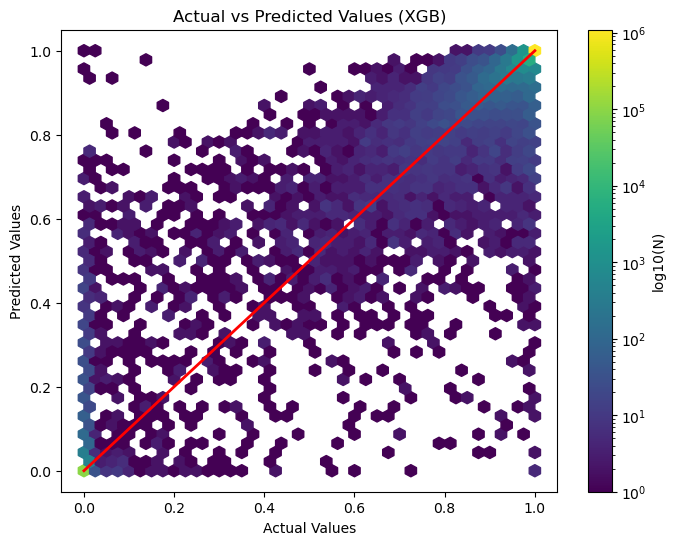

In [ ]:
plt.figure(figsize=(8,6))
plt.hexbin(
    y_test.flatten(), 
    y_pred.flatten(), 
    gridsize=40,  # smaller → finer grid
    cmap='viridis', 
    bins='log'  # logarithmic scaling helps emphasize dense areas
)
plt.colorbar(label='log10(N)')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', lw=2
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (XGB)")
plt.show()


BART

In [ ]:
#BART

# bart_condensates = BART(random_state=0, burnin=100, ndraw=15)
# bart_condensates.fit(X_train, y_train)

In [ ]:
# yhat_test = bart_condensates.predict(X_test.astype(np.float32))

# yhat_test = np.clip(yhat_test, 0, 1)
# np.mean((y_test- yhat_test)**2)

In [ ]:
# var_inclusion = pd.Series(bart_condensates.variable_inclusion_.mean(0),
#  index=D.columns)
# var_inclusion

In [ ]:
overall_end_time = time.time()

totalElapsedTime=overall_end_time - overall_start_time
print(f"The Total Elapsed Time is: {totalElapsedTime/60:.4f} minutes")

The Total Elapsed Time is: 17.7370 minutes
